In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('diabetes_prediction_dataset.csv')
print(df.shape)
df.head()

(100000, 9)


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


# Diabetes Prediction Dataset - Data Collection, Processing & Cleaning
### Cashel Stuger
### COMP 399-004

### Step 1: Initial Data Inspection
Examine dataset structure, data types, and basic information before cleaning

In [29]:
# Display basic information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


### Step 2: Check for and Remove Duplicate Rows

In [30]:
# Check for duplicate rows
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 3854


In [31]:
# Remove duplicate rows
df = df.drop_duplicates()
print("Rows after removing duplicates:", len(df))

Rows after removing duplicates: 96146


**3,854 duplicate rows were identified and removed, reducing the dataset from 100,000 to 96,146 rows.**

### Step 3: Fix Data Types
The age column is stored as float64. I will convert it to int64, to be represented as a whole number (integer)

In [32]:
# Convert age from float to integer
df['age'] = df['age'].astype(int)
print(df['age'].dtype)
df['age'].head(10)

int64


,age
0,80
1,54
2,28
3,36
4,76
5,20
6,44
7,79
8,42
9,32


### Step 4: Investigate and Handle Smoking History Values

In [33]:
# Check all unique values and their counts in smoking_history
print(df['smoking_history'].value_counts())

smoking_history
never          34398
No Info        32887
former          9299
current         9197
not current     6367
ever            3998
Name: count, dtype: int64


In [34]:
# Replace 'No Info' with 'unknown'
df['smoking_history'] = df['smoking_history'].replace('No Info', 'unknown')
print(df['smoking_history'].value_counts())

smoking_history
never          34398
unknown        32887
former          9299
current         9197
not current     6367
ever            3998
Name: count, dtype: int64


**32,887 rows (34%) contained 'No Info' in the smoking_history column. I originally thought that if it was a small value I could just remove these rows. Instead, I just changed the name to unknown. Also changed the value to lowercase as it is with all other categories to ensure consistency.**

### Step 5: Check for Outliers in BMI
BMI values outside a realistic human range may represent data entry errors.
I will examine the distribution and remove any unrealistic values.

In [35]:
# Check BMI statistics and range
print(df['bmi'].describe())

count    96146.000000
mean        27.321461
std          6.767716
min         10.010000
25%         23.400000
50%         27.320000
75%         29.860000
max         95.690000
Name: bmi, dtype: float64


In [36]:
# Remove rows with BMI outside realistic human range (10-60)
before = len(df)
df = df[(df['bmi'] >= 10) & (df['bmi'] <= 60)]
after = len(df)
print(f"Rows removed: {before - after}")
print(f"Rows remaining: {after}")
print(df['bmi'].describe())

Rows removed: 115
Rows remaining: 96031
count    96031.000000
mean        27.274327
std          6.627881
min         10.010000
25%         23.400000
50%         27.320000
75%         29.830000
max         60.000000
Name: bmi, dtype: float64


**BMI values ranged from 10.01 to 95.69. Values above 60 were removed as they fall outside any clinically recognized BMI category. The WHO's highest classification is "severely obese" at BMI 40+, making values above 60 implausible for a general patient population. 115 rows were removed.**

### Step 6: Check for Outliers in Blood Glucose Level
Blood glucose values outside a realistic human range may represent data entry errors. I will examine the distribution and remove any unrealistic values.

In [37]:
# Check blood glucose statistics and range
print(df['blood_glucose_level'].describe())

count    96031.000000
mean       138.197884
std         40.885744
min         80.000000
25%        100.000000
50%        140.000000
75%        159.000000
max        300.000000
Name: blood_glucose_level, dtype: float64


**Blood glucose levels range from 80 to 300 mg/dL with a mean of 138 mg/dL. These values fall within a clinically realistic range. No rows were removed.**

### Step 7: Standardize Text Values
Text columns can have inconsistent casing. I will standardize gender and smoking_history to lowercase.

In [38]:
# Check unique values before standardizing
print("Gender values:", df['gender'].unique())
print("Smoking history values:", df['smoking_history'].unique())

Gender values: ['Female' 'Male' 'Other']
Smoking history values: ['never' 'unknown' 'current' 'former' 'ever' 'not current']


In [39]:
# Standardize gender column to lowercase
df['gender'] = df['gender'].str.lower()

# Verify the change
print("Gender values after standardizing:", df['gender'].unique())

Gender values after standardizing: ['female' 'male' 'other']


**The gender column contained capitalized values ('Female', 'Male', 'Other') which were standardized to lowercase. The smoking_history column was already lowercase.**

### Step 8: Set Proper Decimal Precision

In [40]:
# Check current precision
print("BMI sample before:", df['bmi'].head())
print("HbA1c sample before:", df['HbA1c_level'].head())

# Round to 2 decimal places
df['bmi'] = df['bmi'].round(2)
df['HbA1c_level'] = df['HbA1c_level'].round(2)

# Verify
print("\nBMI sample after:", df['bmi'].head())
print("HbA1c sample after:", df['HbA1c_level'].head())

BMI sample before: 0    25.19
1    27.32
2    27.32
3    23.45
4    20.14
Name: bmi, dtype: float64
HbA1c sample before: 0    6.6
1    6.6
2    5.7
3    5.0
4    4.8
Name: HbA1c_level, dtype: float64

BMI sample after: 0    25.19
1    27.32
2    27.32
3    23.45
4    20.14
Name: bmi, dtype: float64
HbA1c sample after: 0    6.6
1    6.6
2    5.7
3    5.0
4    4.8
Name: HbA1c_level, dtype: float64


**The BMI and HbA1c_level values were already stored at 2 decimal places.**

### Step 9: Verify Valid Value Ranges
I will verify that all columns contain only valid, expected values. For example binary columns should only contain 0 or 1, and age should be within
a realistic human lifespan.

In [41]:
# Verify binary columns only contain 0 and 1
print("Hypertension values:", df['hypertension'].unique())
print("Heart disease values:", df['heart_disease'].unique())
print("Diabetes values:", df['diabetes'].unique())

# Verify age range
print("\nAge range:", df['age'].min(), "to", df['age'].max())

Hypertension values: [0 1]
Heart disease values: [1 0]
Diabetes values: [0 1]

Age range: 0 to 80


**All binary columns (hypertension, heart_disease, diabetes) contain only valid values of 0 and 1 with no unexpected entries. Age ranges from 0 to 80 which falls within a realistic human lifespan. No corrections were needed.**

### Step 10: Rename Columns for Clarity
Some column names are abbreviated or use inconsistent formatting. I will rename them to be more readable and consistent.

In [42]:
# Rename columns for clarity
df = df.rename(columns={
    'HbA1c_level': 'hba1c_level',
    'blood_glucose_level': 'blood_glucose',
    'heart_disease': 'heart_disease_history'
})

# Verify new column names
print(df.columns.tolist())

['gender', 'age', 'hypertension', 'heart_disease_history', 'smoking_history', 'bmi', 'hba1c_level', 'blood_glucose', 'diabetes']


## Data Cleaning Summary

1. Initial data inspection - confirmed 100,000 rows and 9 columns
2. Removed 3,854 duplicate rows - dataset reduced to 96,146 rows
3. Converted age from float64 to int64
4. Replaced 'No Info' with 'unknown' in smoking_history
5. Removed BMI outliers above 60 - removed 115 rows
6. Verified blood glucose range - no rows removed
7. Standardized gender column to lowercase
8. Rounded bmi and hba1c_level to 2 decimal places
9. Verified binary columns and age range - all valid
10. Renamed columns for clarity and consistency

In [43]:
# Final cleaned dataset shape
print("Final dataset shape:", df.shape)
df.head()

Final dataset shape: (96031, 9)


,gender,age,hypertension,heart_disease_history,smoking_history,bmi,hba1c_level,blood_glucose,diabetes
0,female,80,0,1,never,25.19,6.6,140,0
1,female,54,0,0,unknown,27.32,6.6,80,0
2,male,28,0,0,never,27.32,5.7,158,0
3,female,36,0,0,current,23.45,5.0,155,0
4,male,76,1,1,current,20.14,4.8,155,0


### EDA Step 1: Target Variable Distribution
I will examine the balance of the target variable (diabetes) to understand
the proportion of cases in the dataset.

In [44]:
# Count and percentage of diabetes cases
print(df['diabetes'].value_counts())
print("\nPercentage:")
print(df['diabetes'].value_counts(normalize=True) * 100)

diabetes
0    87586
1     8445
Name: count, dtype: int64

Percentage:
diabetes
0    91.205965
1     8.794035
Name: proportion, dtype: float64


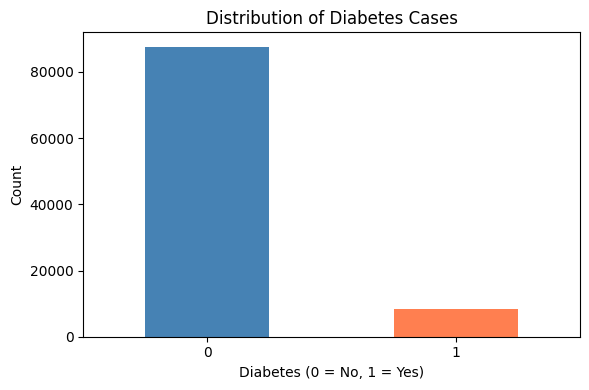

In [45]:
# Visualize target variable distribution
plt.figure(figsize=(6, 4))
df['diabetes'].value_counts().plot(kind='bar', color=['steelblue', 'coral'])
plt.title('Distribution of Diabetes Cases')
plt.xlabel('Diabetes (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**The dataset is significantly imbalanced with 91.5% non-diabetic (91,500) and only 8.5% diabetic (8,500) cases. This reflects real-world diabetes prevalence.**

### EDA Step 2: Age Distribution
I will examine the distribution of patient ages to understand the demographic spread of the dataset and identify any skewness.

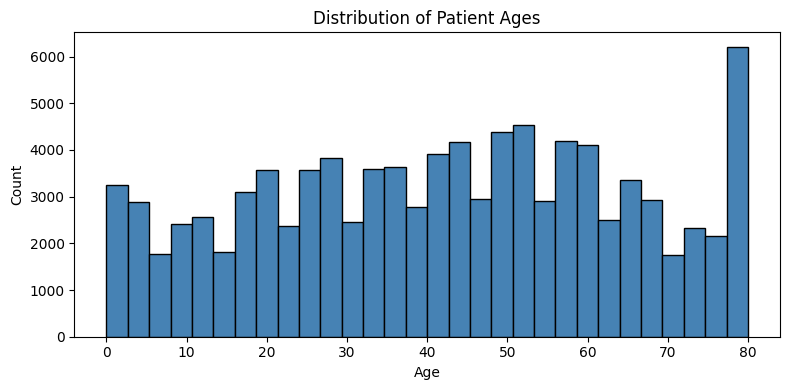

count    96031.000000
mean        41.780644
std         22.490013
min          0.000000
25%         24.000000
50%         43.000000
75%         59.000000
max         80.000000
Name: age, dtype: float64


In [46]:
# Plot age distribution
plt.figure(figsize=(8, 4))
plt.hist(df['age'], bins=30, color='steelblue', edgecolor='black')
plt.title('Distribution of Patient Ages')
plt.xlabel('Age')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Summary statistics
print(df['age'].describe())

**The age distribution is relatively uniform between ages 20-70 with a mean of 41.9 years. There is a notable spike at age 80. This may mean that 80 was the maximum recorded value and older patients were capped at 80. The minimum age of 0.08 indicates newborn patients are included.**

### EDA Step 3: BMI Distribution
I will examine the distribution of BMI values to understand the spread
and identify the most common BMI ranges in the patient population.

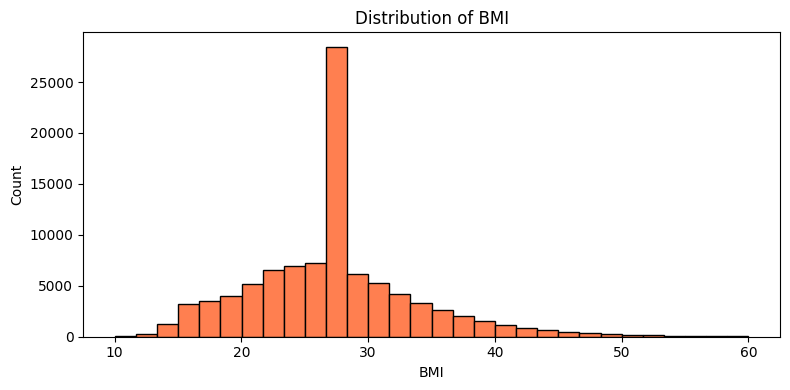

count    96031.000000
mean        27.274327
std          6.627881
min         10.010000
25%         23.400000
50%         27.320000
75%         29.830000
max         60.000000
Name: bmi, dtype: float64


In [47]:
# Plot BMI distribution
plt.figure(figsize=(8, 4))
plt.hist(df['bmi'], bins=30, color='coral', edgecolor='black')
plt.title('Distribution of BMI')
plt.xlabel('BMI')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

print(df['bmi'].describe())

**BMI is right skewed with a mean of 27.27. The right skew indicates more patients trend toward overweight/obese ranges, which aligns with diabetes risk factors.**

### EDA Step 4: Correlation Heatmap
I will examine the correlation between all numeric variables to identify
which features are most strongly related to diabetes.

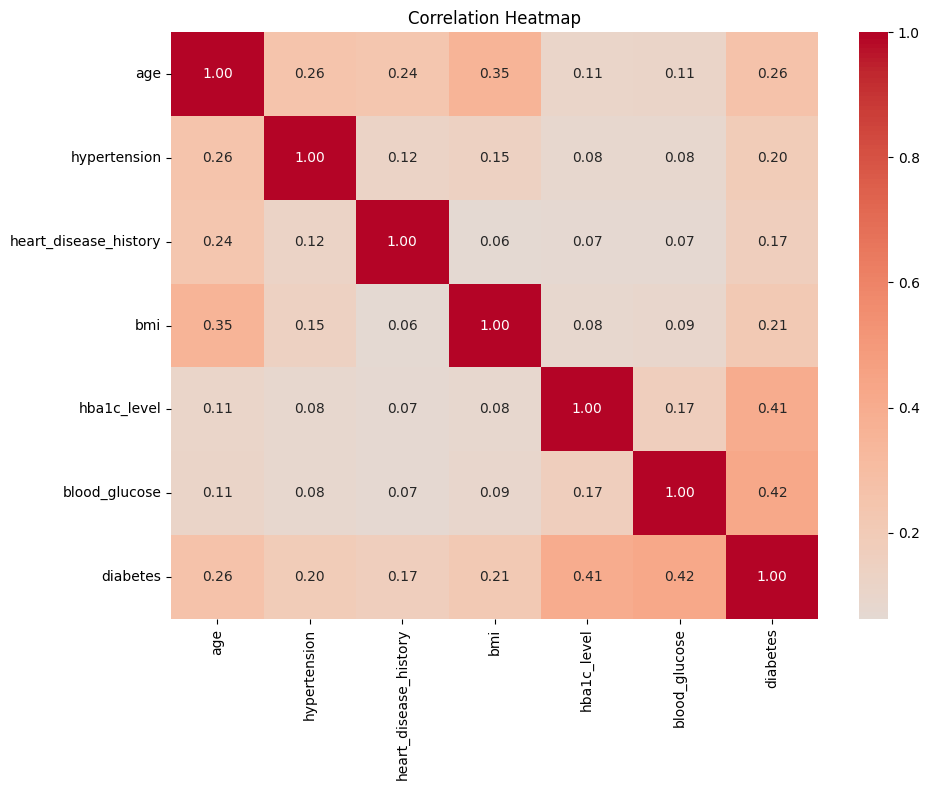

In [48]:
# Correlation heatmap of numeric columns
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f',
            cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

**Blood glucose (0.42) and HbA1c level (0.41) show the strongest correlations with diabetes. BMI (0.21) and age (0.26) show moderate correlations. No features are highly correlated with each other.**

### EDA Step 5: BMI vs Diabetes
I will use a box plot to compare BMI distributions between diabetic and
non-diabetic patients to determine if BMI is an outstanding factor.

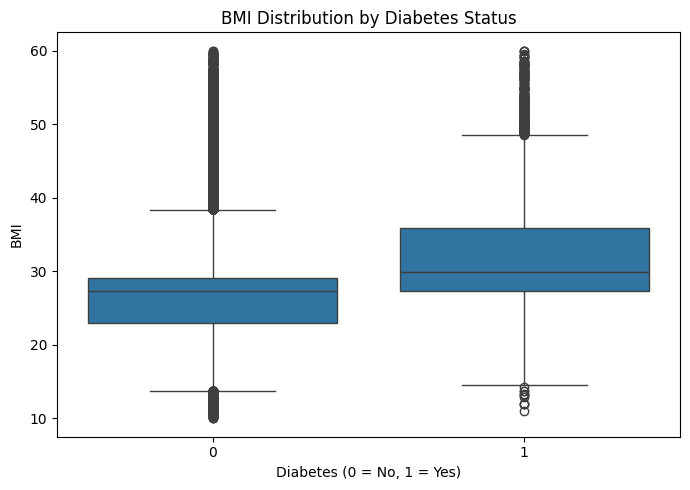

diabetes
0    26.833500
1    31.846302
Name: bmi, dtype: float64


In [50]:
# Box plot of BMI by diabetes status
plt.figure(figsize=(7, 5))
sns.boxplot(x='diabetes', y='bmi', data=df)
plt.title('BMI Distribution by Diabetes Status')
plt.xlabel('Diabetes (0 = No, 1 = Yes)')
plt.ylabel('BMI')
plt.tight_layout()
plt.show()

# Mean BMI by diabetes status
print(df.groupby('diabetes')['bmi'].mean())

**Diabetic patients have a higher BMI with a mean of 31.8 compared to 26.8 for non-diabetic patients. The diabetic group's box sits higher on the scale, confirming BMI as an outstanding factor. A BMI of 31.8 falls in the obese category (WHO defines obesity as BMI ≥ 30), suggesting obesity is strongly associated with diabetes in this dataset.**

### EDA Step 6: Age vs Diabetes
I will compare the age distribution between diabetic and non-diabetic
patients to determine if age is an outstanding factor.

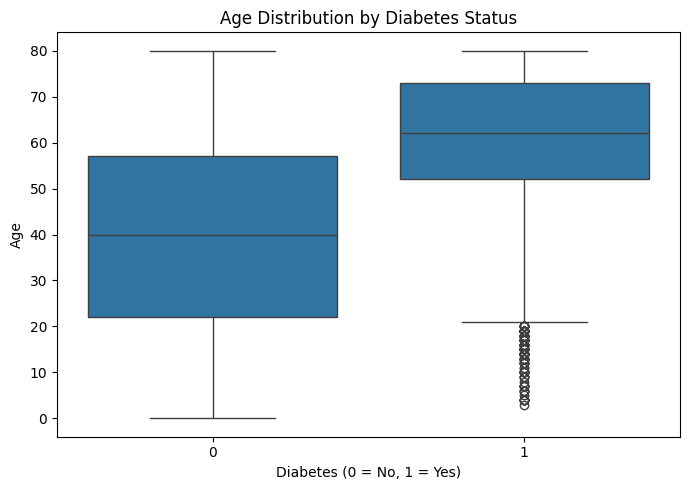

diabetes
0    39.931073
1    60.963173
Name: age, dtype: float64


In [51]:
# Box plot of Age by diabetes status
plt.figure(figsize=(7, 5))
sns.boxplot(x='diabetes', y='age', data=df)
plt.title('Age Distribution by Diabetes Status')
plt.xlabel('Diabetes (0 = No, 1 = Yes)')
plt.ylabel('Age')
plt.tight_layout()
plt.show()

# Mean age by diabetes status
print(df.groupby('diabetes')['age'].mean())

**Diabetic patients are significantly older with a mean age of 61.0 compared to 39.9 for non-diabetic patients. The interquartile ranges barely overlap. I would say this is one of the most outstanding factors so far. This aligns with clinical knowledge that diabetes risk increases substantially with age. The small outlier dots at the bottom of the diabetic group possibly represent rare cases of diabetes in young patients.**

### EDA Step 7: Blood Glucose Distribution
I will examine the distribution of blood glucose levels across the dataset
and compare between diabetic and non-diabetic patients.

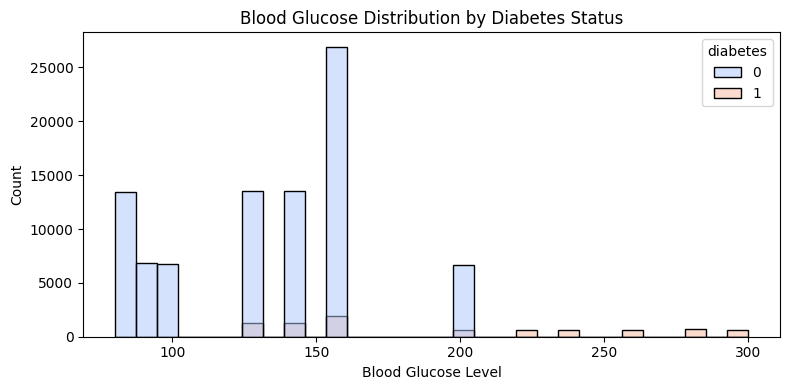

diabetes
0    132.817768
1    193.996921
Name: blood_glucose, dtype: float64


In [54]:
# Plot blood glucose distribution by diabetes status
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='blood_glucose', hue='diabetes',
             bins=30, palette='coolwarm')
plt.title('Blood Glucose Distribution by Diabetes Status')
plt.xlabel('Blood Glucose Level')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

print(df.groupby('diabetes')['blood_glucose'].mean())

**Blood glucose levels show a clear separation between diabetic and non-diabetic patients. Non-diabetic patients cluster below 200 mg/dL with a mean of 132.8, while diabetic patients have a mean of 194.0 mg/dL "Clinically, fasting blood glucose above 126 mg/dL is diagnostic for diabetes", which is consistent with what this chart shows.**

 ### EDA Step 8: HbA1c Level Distribution
I will examine the distribution of HbA1c levels and compare between
diabetic and non-diabetic patients. HbA1c measures average blood
sugar over 3 months and is a key diagnostic marker for diabetes.

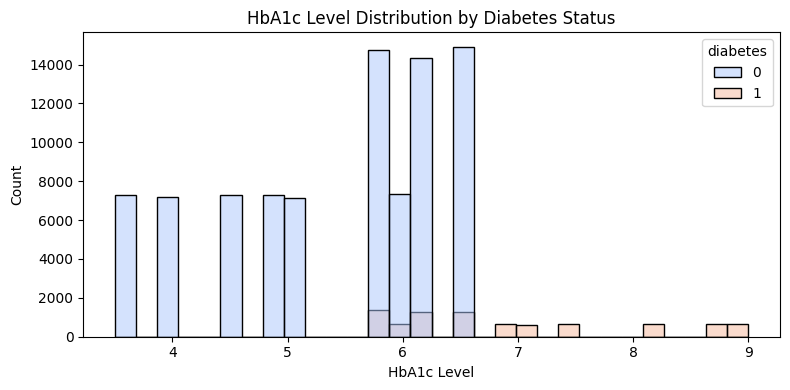

diabetes
0    5.396899
1    6.933724
Name: hba1c_level, dtype: float64


In [55]:
# Plot HbA1c distribution by diabetes status
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='hba1c_level', hue='diabetes',
             bins=30, palette='coolwarm')
plt.title('HbA1c Level Distribution by Diabetes Status')
plt.xlabel('HbA1c Level')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

print(df.groupby('diabetes')['hba1c_level'].mean())

**HbA1c levels show a clear separation between groups, with non-diabetic patients averaging 5.4 and diabetic patients averaging 6.9. "The clinical diagnostic threshold for diabetes is HbA1c ≥ 6.5%", which is clearly reflected in this chart - diabetic patients cluster at and above this threshold while non-diabetic patients are below it.**

### EDA Step 9: Smoking History vs Diabetes
I will examine the diabetes rate across different smoking history categories
to determine if smoking history is associated with diabetes risk.

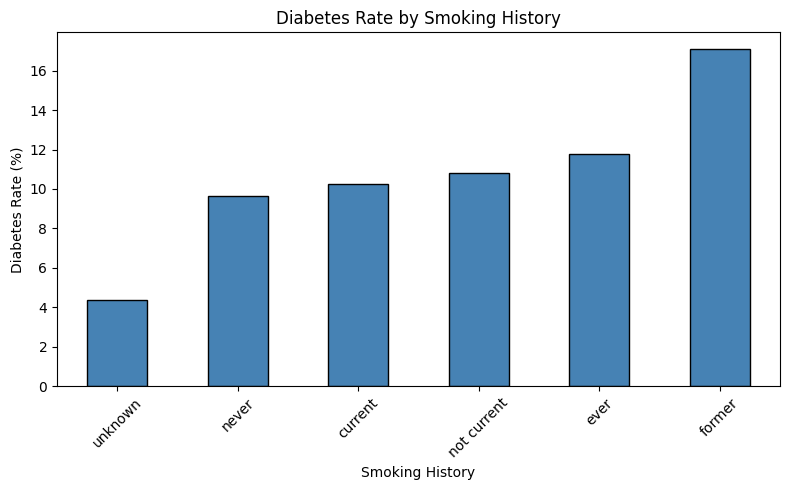

smoking_history
unknown         4.376408
never           9.657602
current        10.270094
not current    10.826524
ever           11.792689
former         17.088403
Name: diabetes, dtype: float64


In [56]:
# Calculate diabetes rate by smoking history
smoking_diabetes = df.groupby('smoking_history')['diabetes'].mean() * 100

# Plot
plt.figure(figsize=(8, 5))
smoking_diabetes.sort_values().plot(kind='bar', color='steelblue',
                                    edgecolor='black')
plt.title('Diabetes Rate by Smoking History')
plt.xlabel('Smoking History')
plt.ylabel('Diabetes Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(smoking_diabetes.sort_values())

**Former smokers have the highest diabetes rate at 17.1%, much higher than current smokers at 10.3% and never smokers at 9.7%. The unknown category has the lowest rate at 4.4%, maybe because it contains patients with incomplete medical histories. Smoking history shows a meaningful association with diabetes.**

### EDA Step 10: Descriptive Statistics Summary
I will compute key statistical measures for all numeric columns including
mean, standard deviation, variance, and (IQR) to summarize the tendency and spread of the dataset.

In [57]:
# Descriptive statistics summary
numeric_cols = ['age', 'bmi', 'hba1c_level', 'blood_glucose',
                'hypertension', 'heart_disease_history', 'diabetes']

stats = pd.DataFrame({
    'Mean': df[numeric_cols].mean(),
    'Std Dev': df[numeric_cols].std(),
    'Variance': df[numeric_cols].var(),
    'Min': df[numeric_cols].min(),
    'Max': df[numeric_cols].max(),
    'IQR': df[numeric_cols].quantile(0.75) - df[numeric_cols].quantile(0.25)
})

print(stats.round(2))

                         Mean  Std Dev  Variance    Min    Max    IQR
age                     41.78    22.49    505.80   0.00   80.0  35.00
bmi                     27.27     6.63     43.93  10.01   60.0   6.43
hba1c_level              5.53     1.07      1.15   3.50    9.0   1.40
blood_glucose          138.20    40.89   1671.64  80.00  300.0  59.00
hypertension             0.08     0.27      0.07   0.00    1.0   0.00
heart_disease_history    0.04     0.20      0.04   0.00    1.0   0.00
diabetes                 0.09     0.28      0.08   0.00    1.0   0.00
